<a href="https://colab.research.google.com/github/Purva1204/DL_LAB_assignments/blob/main/Assignment-2/Assignment_2_MLP_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:

iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Features shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [ ]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data normalization completed.")

Data normalization completed.


In [ ]:

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])


model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1944 - loss: 1.3748 - val_accuracy: 0.3333 - val_loss: 1.3747
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1667 - loss: 1.2681 - val_accuracy: 0.2500 - val_loss: 1.2395
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2037 - loss: 1.1725 - val_accuracy: 0.4167 - val_loss: 1.1196
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3889 - loss: 1.0818 - val_accuracy: 0.5000 - val_loss: 1.0109
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5370 - loss: 0.9972 - val_accuracy: 0.6667 - val_loss: 0.9149
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6019 - loss: 0.9222 - val_accuracy: 0.5000 - val_loss: 0.8364
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6574 - loss: 0.8578 - val_accuracy: 0.5833 - val_loss: 0.7655
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6389 - loss: 0.7998 - val_accuracy: 0.5833 - val_loss

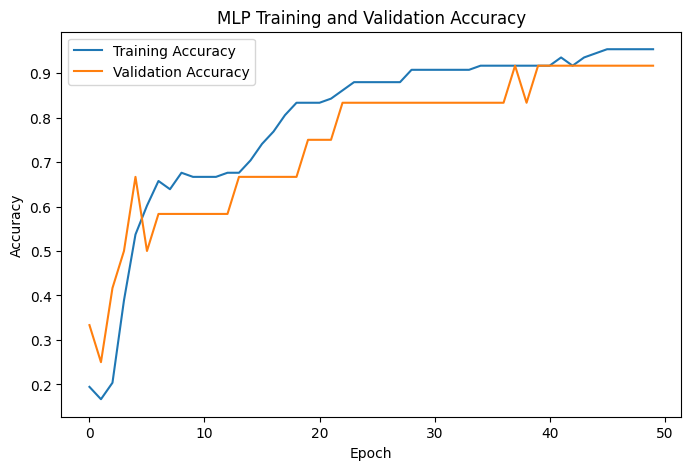

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Training and Validation Accuracy')
plt.legend()
plt.show()

In [ ]:

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Test Accuracy: 0.9
Test Accuracy (%): 90.0


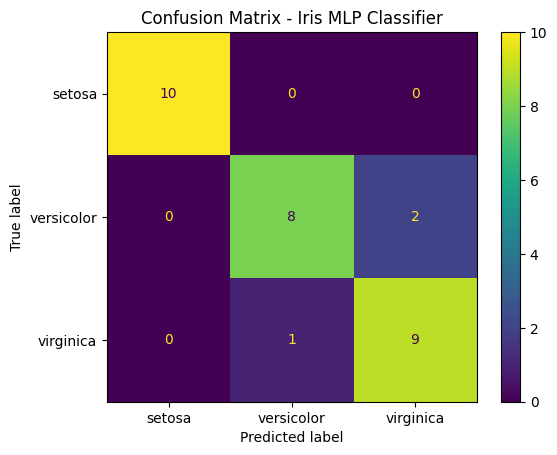

In [ ]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Iris MLP Classifier")
plt.show()

In [ ]:
print("----- Final Results -----")
print("Dataset: Iris")
print("Model: Multilayer Perceptron (MLP)")
print("Number of classes:", len(iris.target_names))
print("Test Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(cm)

----- Final Results -----
Dataset: Iris
Model: Multilayer Perceptron (MLP)
Number of classes: 3
Test Accuracy: 90.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]
